# Environment

In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.1)

In [ ]:
# @title Constants
EVENT_DURATION = 180 #minutes
NUM_SIMULATIONS = 500
TIMESTEP = 0.5
TOTAL_PEOPLE = 50
LAMBDA_GAIN = 0.2
TRAVEL_COST = 1 #Minutes
T_SUCCESS = 5
P_0 = 0.3
T_CONTROL=10.0

In [ ]:
# @title Free Parameters
ddm_threshold        = (0.65, 0.70, 0.75, 0.80, 0.85)
p_cue                = (0.6, 0.7, 0.8)
employer_percentages = (0.30, 0.50, 0.70)
lambda_values        = (0.1, 0.3, 0.5, 0.7, 0.9)
epsilon_values       = (0.1, 0.3, 0.5, 0.7, 0.9)
emp_vals             = employer_percentages

This will generate 103 conditions in total with:

*  Control: 3 conditions(lean, medium and rich environment)
*  Epsilon-greedy: 5*3 = 15 conditions
*  MVT: 3* 3 * 5 = 45 conditions
*  DDM: 3* 3 * 5 = 45 conditions

# Helper Functions

In [ ]:
def get_cue(has_job: bool, q: float) -> int:
    """
    J = 1: positive cue with probability q (false negative: 1-q)
    J = 0: negative cue with probability 1-q (false positve: q)
    """
    p_pos = q if has_job else (1.0 - q)
    return 1 if np.random.rand() < p_pos else 0


def bayes_update(prior: float, q: float, cue: int) -> float:
    """Bayesian update in log-odds space."""
    prior = min(max(prior, 1e-9), 1 - 1e-9)   # clamp to avoid log(0)
    llr = math.log(q / (1.0 - q))
    log_odds = math.log(prior / (1.0 - prior)) + (llr if cue == 1 else -llr)
    return 1.0 / (1.0 + math.exp(-log_odds))


def information_gain(t: float, lam: float) -> float:
    """h(t) = 1 - exp(-lambda * t)"""
    return 1 - math.exp(-lam * t)


def generate_people(employer_pct: float) -> list:
    n = round(TOTAL_PEOPLE * employer_pct)
    people = [True] * n + [False] * (TOTAL_PEOPLE - n)
    np.random.shuffle(people)
    return people

# Control

In [ ]:
def simulate_control_agent(people_list: list[bool]):
    successful_interactions = 0
    time_elapsed = 0.0
    people_visited = 0
    interaction_log = []

    timesteps_per_person = int(T_CONTROL/TIMESTEP) #12 time steps

    for i, person in enumerate(people_list):

        if time_elapsed >= EVENT_DURATION:
            break
        people_visited += 1
        interaction_time = 0.0

        for step in range(timesteps_per_person):
            if time_elapsed >= EVENT_DURATION:
                break
            time_elapsed += TIMESTEP
            interaction_time += TIMESTEP

        # Determine if the interaction was successful
        success = person and (interaction_time >= T_SUCCESS)

        if success:
            successful_interactions += 1

        interaction_log.append({
            "person_index": i,
            "has_job": person,
            "success": success, # Explicitly add success key
            "contacts_so_far": successful_interactions,
            "time_in_convo": interaction_time,
            "time_elapsed": time_elapsed
        })

        if i < len(people_list) - 1:
            time_elapsed = min(time_elapsed + TRAVEL_COST, EVENT_DURATION)

    return {
        "agent"  : "baseline",
        "contacts": successful_interactions,
        "people_visited": people_visited,
        "log": interaction_log
    }

# Epsilon Greedy

In [ ]:
def simulate_epsilon_greedy(people_list: list[bool], epsilon: float) -> dict:
    successful_interactions = 0
    time_elapsed   = 0.0
    people_visited = 0
    interaction_log = []

    for i, has_job in enumerate(people_list):
        if time_elapsed >= EVENT_DURATION:
            break

        time_in_convo = 0.0

        while time_elapsed < EVENT_DURATION:
            time_elapsed  += TIMESTEP
            time_in_convo += TIMESTEP
            if np.random.rand() < epsilon:
                break

        people_visited += 1
        success = has_job and (time_in_convo >= T_SUCCESS)
        if success:
            successful_interactions += 1

        if i < len(people_list) - 1 and time_elapsed < EVENT_DURATION:
            time_elapsed = min(time_elapsed + TRAVEL_COST, EVENT_DURATION)

        interaction_log.append({
            "person_index"   : i,
            "has_job"        : has_job,
            "time_in_convo"  : round(time_in_convo, 2),
            "success"        : success,
            "contacts_so_far": successful_interactions,
            "time_elapsed"   : round(time_elapsed, 2),
        })

    return {
        "agent"          : "epsilon_greedy",
        "contacts"       : successful_interactions,
        "people_visited" : people_visited,
        "log"            : interaction_log,
    }





# MVT


In [ ]:
def simulate_mvt_agent(people_list: list, q: float, lambda_var: float) -> dict:
    """
    MVT with posterior-weighted reward signal.

    Step reward = P(job|cues) × marginal information gain
    This makes R_bar = expected posterior-weighted gain per minute,
    which is comparable across patches.
    """
    contacts, t, log = 0, 0.0, []
    min_steps = int(T_SUCCESS / TIMESTEP)
    total_reward, total_time = 0.0, 0.0
    R_bar = (P_0 * information_gain(T_CONTROL, lambda_var)) / (T_CONTROL + TRAVEL_COST)

    for i, has_job in enumerate(people_list):
        if t >= EVENT_DURATION: break
        posterior, t_conv, step, patch_reward = P_0, 0.0, 0, 0.0

        while t < EVENT_DURATION:
            cue = get_cue(has_job, q)
            posterior = bayes_update(posterior, q, cue)
            t += TIMESTEP; t_conv += TIMESTEP; step += 1

            h_now  = information_gain(t_conv,           lambda_var)
            h_prev = information_gain(t_conv - TIMESTEP, lambda_var)
            h_next = information_gain(t_conv + TIMESTEP, lambda_var)

            # Posterior-weighted step reward
            step_reward    = posterior * (h_now - h_prev)
            patch_reward  += step_reward

            reward_rate   = patch_reward / t_conv
            next_marginal = posterior * (h_next - h_now)   # prospective value

            if step >= min_steps and (reward_rate <= R_bar or next_marginal <= R_bar):
                break

        total_time   += t_conv
        total_reward += patch_reward
        R_bar = total_reward / (total_time + TRAVEL_COST * max(1, len(log)))

        success = has_job and (t_conv >= T_SUCCESS)
        if success: contacts += 1
        log.append({"person_index": i, "has_job": has_job, "success": success,
                    "contacts_so_far": contacts, "time_in_convo": round(t_conv, 2),
                    "time_elapsed": round(t, 2), "R_bar": round(R_bar, 5),
                    "posterior": round(posterior, 4)})
        if i < len(people_list) - 1 and t < EVENT_DURATION:
            t = min(t + TRAVEL_COST, EVENT_DURATION)

    return {"agent": "mvt", "contacts": contacts,
            "people_visited": len(log), "log": log}

# Drift Diffusion

In [ ]:
def simulate_ddm_agent(people_list: list[bool], q: float, p: float) -> dict:

    successful_interactions = 0
    time_elapsed   = 0.0
    people_visited = 0
    interaction_log = []
    person_idx = 0

    max_steps = int(T_CONTROL / TIMESTEP)

    for i, has_job in enumerate(people_list):
        if time_elapsed >= EVENT_DURATION:
          break
        posterior, t_conv, step, exit_reason = P_0, 0.0, 0, "timeout"

        while time_elapsed < EVENT_DURATION and step < max_steps:
            cue = get_cue(has_job, q)
            posterior = bayes_update(posterior, q, cue)
            time_elapsed += TIMESTEP;
            t_conv += TIMESTEP;
            step += 1

            if posterior <= 1.0 - p:
                exit_reason = "lower"; break      # confident no job → leave NOW
            if posterior >= p:
                exit_reason = "upper"             # confident yes job → note, keep going

        success = has_job and (t_conv >= T_SUCCESS)
        if success:
          successful_interactions += 1

        interaction_log.append({"person_index": i, "has_job": has_job, "success": success,
                    "contacts_so_far": successful_interactions, "time_in_convo": round(t_conv, 2),
                    "time_elapsed": round(time_elapsed, 2), "posterior": round(posterior, 4),
                    "exit_reason": exit_reason})
        if i < len(people_list) - 1 and time_elapsed < EVENT_DURATION:
            time_elapsed = min(time_elapsed + TRAVEL_COST, EVENT_DURATION)

    return {"agent": "ddm", "contacts": successful_interactions,
            "people_visited": len(interaction_log), "log": interaction_log}


# Lean VS. Rich Environment: Parameter sweep

---



In [ ]:
def run_agent(agent_name: str, params: dict) -> dict:
    results = np.zeros(NUM_SIMULATIONS)
    people_visited_per_sim = np.zeros(NUM_SIMULATIONS) # Initialize array to store people_visited counts
    all_logs = []   # pool every conversation log across all 500 simulations

    for s in range(NUM_SIMULATIONS):
        people = generate_people(params["employer_pct"])
        if   agent_name == "baseline":
            r = simulate_control_agent(people)
        elif agent_name == "epsilon_greedy":
            r = simulate_epsilon_greedy(people, params["epsilon"])
        elif agent_name == "mvt":
            r = simulate_mvt_agent(people, params["q"], params["lam"])
        elif agent_name == "ddm":
            r = simulate_ddm_agent(people, params["q"], params["eta"])
        results[s] = r["contacts"]
        people_visited_per_sim[s] = r["people_visited"] # Store people_visited for current simulation
        all_logs.extend(r["log"])   # accumulate all conversation entries

    return {"agent": agent_name, "mean": float(np.mean(results)),
            "std": float(np.std(results)), "all_contacts": results,
            "mean_visited": float(np.mean(people_visited_per_sim)), # Add mean_visited to the returned dictionary
            "all_logs": all_logs}   # 500 sims × ~50 people = ~25,000 entries(probably less)

In [ ]:
def run_parameter_sweep():
    records = []

    for emp in employer_percentages:
        r = run_agent("baseline", {"employer_pct": emp})
        records.append({**r, "employer_pct": emp, "q": None,
                        "lam": None, "eta": None, "epsilon": None})
        print(f"[+] baseline  | emp={emp:.0%}  mean={r['mean']:.2f}")

    for emp in employer_percentages:
        for eps in epsilon_values:
            r = run_agent("epsilon_greedy", {"employer_pct": emp, "epsilon": eps})
            records.append({**r, "employer_pct": emp, "q": None,
                            "lam": None, "eta": None, "epsilon": eps})
        print(f"[+] e-greedy  | emp={emp:.0%}")

    for emp in employer_percentages:
        for q_val in p_cue:
            for lam_val in lambda_values:
                r = run_agent("mvt", {"employer_pct": emp, "q": q_val, "lam": lam_val})
                records.append({**r, "employer_pct": emp, "q": q_val,
                                "lam": lam_val, "eta": None, "epsilon": None})
        print(f"[+] mvt       | emp={emp:.0%}")

    for emp in employer_percentages:
        for q_val in p_cue:
            for eta_val in ddm_threshold:
                r = run_agent("ddm", {"employer_pct": emp, "q": q_val, "eta": eta_val})
                records.append({**r, "employer_pct": emp, "q": q_val,
                                "lam": None, "eta": eta_val, "epsilon": None})
        print(f"[+] ddm       | emp={emp:.0%}")

    df = pd.DataFrame([{k: v for k, v in r.items() if k != "all_contacts"}
                        for r in records])
    return df, records


df_results, all_records = run_parameter_sweep()
print("Done. Shape:", df_results.shape)

[+] baseline  | emp=30%  mean=4.74
[+] baseline  | emp=50%  mean=7.96
[+] baseline  | emp=70%  mean=11.25
[+] e-greedy  | emp=30%
[+] e-greedy  | emp=50%
[+] e-greedy  | emp=70%
[+] mvt       | emp=30%
[+] mvt       | emp=50%
[+] mvt       | emp=70%
[+] ddm       | emp=30%


## Verifying the sweep

In [ ]:
# how many conditions per agent?
print(df_results.groupby("agent").size())

# spot check — all employer_pct × q combinations for DDM?
ddm_check = df_results[df_results.agent == "ddm"]
print(ddm_check.groupby(["employer_pct","q"]).size())

# any missing conditions?
print(df_results.isnull().sum())

In [ ]:
AGENTS = ["baseline", "epsilon_greedy", "mvt", "ddm"]
ENV = {0.30: "Lean(30%)", 0.50: "Equal(50%)", 0.70: "Rich(70%)"}

print("BEST PER AGENT BY ENVIRONMENT")
for emp in emp_vals:
    print(f"\n  {ENV[emp]}:")
    for ag in AGENTS:
        sub = [r for r in all_records if r["agent"] == ag and r["employer_pct"] == emp]
        if not sub:
            continue
        best = max(sub, key=lambda x: x["mean"])
        print(f"    {ag:15s}  mean={best['mean']:.2f}  std={best['std']:.2f}")

# Comparison


In [ ]:
AGENT_ORDER  = ["baseline", "epsilon_greedy", "mvt", "ddm"]
AGENT_LABELS = {
    "baseline":       "Baseline\n(fixed 10min)",
    "epsilon_greedy": "ε-greedy",
    "mvt":            "MVT",
    "ddm":            "DDM",
}
AGENT_COLORS = {
    "baseline":       "#888899",
    "epsilon_greedy": "#2ECC71",
    "mvt":            "#E67E22",
    "ddm":            "#9B59B6",
}
ENV_LABELS = {0.30: "Lean (30%)", 0.50: "Equal (50%)", 0.70: "Rich (70%)"}
ENV_COLORS = {0.30: "#5DADE2",   0.50: "#F4D03F",    0.70: "#EC7063"}

## Figure 1 - Which agent performs better on average across the environments?

In [ ]:
def fig1_overall_distribution(all_records):
    best = {a: max([r for r in all_records if r["agent"]==a], key=lambda x: x["mean"])
            for a in AGENT_ORDER}

    rows = []
    for a in AGENT_ORDER:
        for v in best[a]["all_contacts"]:
            rows.append({"Agent": AGENT_LABELS[a], "Contacts": v})
    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle("Figure 1 — Contact distribution per agent (best parameter setting, 500 simulations)",
                 fontsize=12, y=1.01)
    sns.violinplot(data=df, x="Agent", y="Contacts", hue="Agent", legend=False,
                   palette=[AGENT_COLORS[a] for a in AGENT_ORDER],
                   inner="box", cut=0, linewidth=0.8, ax=ax,
                   order=[AGENT_LABELS[a] for a in AGENT_ORDER])
    for i, a in enumerate(AGENT_ORDER):
        m = best[a]["mean"]
        ax.text(i, m+0.4, f"{m:.1f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=AGENT_COLORS[a])
    ax.set_xlabel(""); ax.set_ylabel("Contacts made per event")
    sns.despine(ax=ax); plt.tight_layout()
    plt.savefig("fig1_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

fig1_overall_distribution(all_records)

## Figure 2 — Does the environment (how many jobs exist) change who wins?


In [ ]:
def fig2_by_environment(all_records):
    # Compute global y-max across ALL environments and agents before drawing
    all_tops = []
    for emp in emp_vals:
        for a in AGENT_ORDER:
            sub = [r for r in all_records if r["agent"]==a and r["employer_pct"]==emp]
            if sub:
                best = max(sub, key=lambda x: x["mean"])
                all_tops.append(best["mean"] + best["std"])
    y_max = max(all_tops) * 1.18   # headroom for star label

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle("Figure 2 — Mean contacts by environment condition", fontsize=12, y=1.01)
    for ax, emp in zip(axes, emp_vals):
        means, stds, colors = [], [], []
        for a in AGENT_ORDER:
            sub = [r for r in all_records if r["agent"]==a and r["employer_pct"]==emp]
            best = max(sub, key=lambda x: x["mean"]) if sub else None
            means.append(best["mean"] if best else 0)
            stds.append(best["std"]   if best else 0)
            colors.append(AGENT_COLORS[a])
        ax.bar([AGENT_LABELS[a] for a in AGENT_ORDER], means, yerr=stds, capsize=4,
               color=colors, alpha=0.85, linewidth=0,
               error_kw={"ecolor": "#33333344", "lw": 1.2})
        ax.set_title(ENV_LABELS[emp], color=ENV_COLORS[emp], fontsize=11)
        ax.set_ylabel("Mean contacts" if ax is axes[0] else "")
        ax.set_ylim(0, y_max)          # same scale on every subplot
        ax.tick_params(axis="x", rotation=20); sns.despine(ax=ax)
        wi = int(np.argmax(means))
        ax.text(wi, means[wi]+stds[wi]+0.3, "★", ha="center", fontsize=14, color="#FFD700")
    plt.tight_layout()
    plt.savefig("fig2_by_environment.png", dpi=150, bbox_inches="tight")
    plt.show()

fig2_by_environment(all_records)

## Figure 3 — When does inference (DDM) beat rate-tracking (MVT)? At what cue reliability does DDM's inference outperform MVT's rate-tracking?

In [ ]:
def fig3_ddm_vs_mvt(all_records):
    q_vals = sorted({r["q"] for r in all_records if r["q"] is not None})

    # Compute global y-max across ALL environments and agents before drawing => so we can see the concise comparison
    #prev.v = had scaling
    all_vals = []
    for emp in emp_vals:
        for agent in ["ddm", "mvt"]:
            for q in q_vals:
                sub = [r for r in all_records
                       if r["agent"]==agent and r["q"]==q and r["employer_pct"]==emp]
                if sub:
                    all_vals.append(np.mean([r["mean"] for r in sub]))
    y_max = max(all_vals) * 1.15

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    fig.suptitle("Figure 3 — DDM vs MVT: sensitivity to cue validity q", fontsize=12, y=1.01)
    for ax, emp in zip(axes, emp_vals):
        for agent, marker, ls in [("ddm","o","-"),("mvt","s","--")]:
            means = [np.mean([r["mean"] for r in all_records
                              if r["agent"]==agent and r["q"]==q and r["employer_pct"]==emp] or [0])
                     for q in q_vals]
            ax.plot(q_vals, means, marker=marker, ls=ls, lw=2,
                    color=AGENT_COLORS[agent],
                    label=AGENT_LABELS[agent].replace("\n"," "), markersize=8)
        bl_mean = np.mean([r["mean"] for r in all_records
                           if r["agent"]=="baseline" and r["employer_pct"]==emp] or [0])
        ax.axhline(bl_mean, color=AGENT_COLORS["baseline"], lw=1.5, ls=":",
                   label="Baseline", alpha=0.7)
        ax.set_title(ENV_LABELS[emp], color=ENV_COLORS[emp], fontsize=11)
        ax.set_xlabel("Cue validity q")
        ax.set_ylabel("Mean contacts" if ax is axes[0] else "")
        ax.set_ylim(0, y_max)          # same scale on every subplot
        ax.set_xticks(q_vals); ax.legend(fontsize=9); sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("fig3_ddm_vs_mvt.png", dpi=150, bbox_inches="tight")
    plt.show()

fig3_ddm_vs_mvt(all_records)

## Figure 4 -DDM residence time as it exits non-job-holders almost immediately, while spending the full conversation window with job-holders.

In [ ]:
def fig4_ddm_residence(all_records):
    """
    Reads directly from the sweep logs — no re-simulation needed.
    Best DDM config (equal env): 500 sims × ~50 people = ~25,000 conversations.
    """
    sub = [r for r in all_records if r["agent"]=="ddm" and r["employer_pct"]==0.50]
    best = max(sub, key=lambda x: x["mean"])
    q, eta = best["q"], best["eta"]

    logs = best["all_logs"]   # already collected during sweep
    times_job = [e["time_in_convo"] for e in logs if e["has_job"]]
    times_noj = [e["time_in_convo"] for e in logs if not e["has_job"]]
    n_total = len(logs)

    # Shared bins and y-limit across both panels
    shared_bins = np.linspace(0, T_CONTROL + 0.5, 22)
    counts_job, _ = np.histogram(times_job, bins=shared_bins)
    counts_noj, _ = np.histogram(times_noj, bins=shared_bins)
    y_max = max(counts_job.max(), counts_noj.max()) * 1.15

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"Figure 4 — DDM residence time by conversation type (q={q}, η={eta})\n"
        f"From sweep logs: 500 simulations × ~50 people = {n_total:,} conversations",
        fontsize=12, y=1.02)

    for ax, times, color, title in [
        (axes[0], times_job, AGENT_COLORS["ddm"], "Job-holders (Ji=1)"),
        (axes[1], times_noj, "#E74C3C",            "Non-job-holders (Ji=0)"),
    ]:
        ax.hist(times, bins=shared_bins, color=color, alpha=0.85, edgecolor="white", lw=0.4)
        ax.axvline(T_SUCCESS, color="#FFD700", lw=2, ls="--",
                   label=f"T_success={T_SUCCESS}min")
        ax.axvline(np.mean(times), color="white", lw=1.5, ls=":",
                   label=f"mean={np.mean(times):.1f}min")
        ax.set_title(title,
                     color="#2ECC71" if "Job" in title else "#E74C3C", fontsize=11)
        ax.set_xlabel("Time in conversation (min)")
        ax.set_ylabel("Count" if ax is axes[0] else "")
        ax.set_xlim(0, T_CONTROL + 0.5)
        ax.set_ylim(0, y_max)
        ax.legend(fontsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("fig4_ddm_residence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"n={n_total:,}  mean time — job-holders: {np.mean(times_job):.2f}min  "
          f"non-job-holders: {np.mean(times_noj):.2f}min")

fig4_ddm_residence(all_records)

## Figure 5 - Residence Time Across All Agents

In [ ]:
def fig5_residence_all_agents(all_records):
    """
    For each agent at best params (equal env), shows the PROPORTION of
    conversations spent at each duration bin, split by job status.
    Using proportion (not raw count) makes agents with different visit
    rates directly comparable.
    All panels share x and y axes.
    """
    shared_bins = np.linspace(0, T_CONTROL + 0.5, 22)
    bin_centers = (shared_bins[:-1] + shared_bins[1:]) / 2
    width = (shared_bins[1] - shared_bins[0]) * 0.42

    agent_props = {}
    for ag in AGENT_ORDER:
        sub = [r for r in all_records if r["agent"]==ag and r["employer_pct"]==0.50]
        best = max(sub, key=lambda x: x["mean"])
        logs = best["all_logs"]
        times_job = [e["time_in_convo"] for e in logs if e["has_job"]]
        times_noj = [e["time_in_convo"] for e in logs if not e["has_job"]]
        n_total = len(logs)
        # Proportion of ALL conversations (job + no-job combined) in each bin
        c_job, _ = np.histogram(times_job, bins=shared_bins)
        c_noj, _ = np.histogram(times_noj, bins=shared_bins)
        agent_props[ag] = (c_job / n_total, c_noj / n_total,
                           np.mean(times_job), np.mean(times_noj), n_total)

    y_max = max(max(p[0].max(), p[1].max()) for p in agent_props.values()) * 1.2

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(
        "Figure 5 — Patch residence time per agent\n"
        "Proportion of all conversations at each duration (green=job-holder, red=no job) | Equal env (50%)",
        fontsize=12, y=1.04)

    for ax, ag in zip(axes, AGENT_ORDER):
        prop_job, prop_noj, mean_job, mean_noj, n = agent_props[ag]
        # Side-by-side bars: job left, no-job right of each bin center
        ax.bar(bin_centers - width/2, prop_job, width=width,
               color="#2ECC71", alpha=0.85, label=f"Ji=1 (mean={mean_job:.1f}min)",
               edgecolor="white", lw=0.3)
        ax.bar(bin_centers + width/2, prop_noj, width=width,
               color="#E74C3C", alpha=0.85, label=f"Ji=0 (mean={mean_noj:.1f}min)",
               edgecolor="white", lw=0.3)
        ax.axvline(T_SUCCESS, color="#FFD700", lw=1.5, ls="--", alpha=0.9,
                   label=f"T_min={T_SUCCESS}min")
        ax.set_title(AGENT_LABELS[ag].replace("\n", " "),
                     color=AGENT_COLORS[ag], fontsize=10)
        ax.set_xlabel("Min in conversation")
        ax.set_ylabel("Proportion of conversations" if ax is axes[0] else "")
        ax.set_xlim(0, T_CONTROL + 0.5)
        ax.set_ylim(0, y_max)
        ax.legend(fontsize=7.5)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("fig5_residence_all_agents.png", dpi=150, bbox_inches="tight")
    plt.show()

fig5_residence_all_agents(all_records)

## Figure 6 - Free Parameter Sensitivity by agent


In [ ]:
def fig6_param_sensitivity(all_records):
    """
    Sensitivity of each agent to its free parameter, across environments.
    All panels share the same y-axis so cross-agent comparisons are fair.
    """
    eta_vals = sorted({r["eta"] for r in all_records if r["eta"] is not None})
    lam_vals = sorted({r["lam"] for r in all_records if r["lam"] is not None})
    eps_vals = sorted({r["epsilon"] for r in all_records if r["epsilon"] is not None})
    linestyles = ["-", "--", ":"]

    # Global y-max across all three panels
    all_means = []
    for emp in emp_vals:
        for eta in eta_vals:
            sub = [r for r in all_records if r["agent"]=="ddm"
                   and r["eta"]==eta and r["employer_pct"]==emp]
            if sub: all_means.append(np.mean([r["mean"] for r in sub]))
        for lam in lam_vals:
            sub = [r for r in all_records if r["agent"]=="mvt"
                   and r["lam"]==lam and r["employer_pct"]==emp]
            if sub: all_means.append(np.mean([r["mean"] for r in sub]))
        for eps in eps_vals:
            sub = [r for r in all_records if r["agent"]=="epsilon_greedy"
                   and r["epsilon"]==eps and r["employer_pct"]==emp]
            if sub: all_means.append(np.mean([r["mean"] for r in sub]))
    y_max = max(all_means) * 1.12

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Figure 6 — Free parameter sensitivity per agent", fontsize=12, y=1.01)

    # DDM — eta
    ax = axes[0]
    for emp, ls in zip(emp_vals, linestyles):
        means = [np.mean([r["mean"] for r in all_records if r["agent"]=="ddm"
                          and r["eta"]==eta and r["employer_pct"]==emp] or [0])
                 for eta in eta_vals]
        ax.plot(eta_vals, means, ls, lw=2, color=AGENT_COLORS["ddm"],
                marker="o", markersize=7, label=ENV_LABELS[emp],
                alpha=0.5 + 0.25 * emp_vals.index(emp))
    ax.set_xlabel("DDM threshold η"); ax.set_ylabel("Mean contacts")
    ax.set_title("DDM — confidence threshold η", color=AGENT_COLORS["ddm"], fontsize=11)
    ax.set_ylim(0, y_max); ax.legend(fontsize=8); sns.despine(ax=ax)

    # MVT — lambda
    ax = axes[1]
    for emp, ls in zip(emp_vals, linestyles):
        means = [np.mean([r["mean"] for r in all_records if r["agent"]=="mvt"
                          and r["lam"]==lam and r["employer_pct"]==emp] or [0])
                 for lam in lam_vals]
        ax.plot(lam_vals, means, ls, lw=2, color=AGENT_COLORS["mvt"],
                marker="s", markersize=7, label=ENV_LABELS[emp],
                alpha=0.5 + 0.25 * emp_vals.index(emp))
    ax.set_xlabel("Information gain rate λ"); ax.set_ylabel("")
    ax.set_title("MVT — information gain rate λ", color=AGENT_COLORS["mvt"], fontsize=11)
    ax.set_ylim(0, y_max); ax.legend(fontsize=8); sns.despine(ax=ax)

    # ε-greedy — epsilon
    ax = axes[2]
    for emp, ls in zip(emp_vals, linestyles):
        means = [np.mean([r["mean"] for r in all_records if r["agent"]=="epsilon_greedy"
                          and r["epsilon"]==eps and r["employer_pct"]==emp] or [0])
                 for eps in eps_vals]
        ax.plot(eps_vals, means, ls, lw=2, color=AGENT_COLORS["epsilon_greedy"],
                marker="^", markersize=7, label=ENV_LABELS[emp],
                alpha=0.5 + 0.25 * emp_vals.index(emp))
    ax.set_xlabel("Leave probability ε"); ax.set_ylabel("")
    ax.set_title("ε-greedy — leave probability ε",
                 color=AGENT_COLORS["epsilon_greedy"], fontsize=11)
    ax.set_ylim(0, y_max); ax.legend(fontsize=8); sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("fig6_param_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()

fig6_param_sensitivity(all_records)

## Figure 7 Efficiency: People Visited vs Contacts Made


In [ ]:
def fig7_efficiency(all_records):
    emp_vals = [0.30, 0.50, 0.70]

    all_x, all_y = [], []
    for ag in AGENT_ORDER:
        for emp in emp_vals:
            sub = [r for r in all_records
                   if r["agent"] == ag and r["employer_pct"] == emp]
            if not sub: continue
            best = max(sub, key=lambda x: x["mean"])
            all_x.append(best["mean_visited"])
            all_y.append(best["mean"])

    x_max = max(all_x) * 1.15
    y_max = max(all_y) * 1.15

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "Figure 7 — Efficiency: people visited vs successful contacts made\n"
        "Dashed line = oracle ceiling: successful_contacts = visited × employer_pct",
        fontsize=12, y=1.04
    )

    for ax, emp in zip(axes, emp_vals):
        x_line = np.array([0, x_max])

        # correct slope is employer_pct — label it explicitly
        ax.plot(x_line, x_line * emp, ls="--", lw=1.5,
                color="#AAAAAA", alpha=0.7, zorder=1,
                label=f"Oracle ceiling\n(slope = {emp:.0%} job density)")

        for ag in AGENT_ORDER:
            sub = [r for r in all_records
                   if r["agent"] == ag and r["employer_pct"] == emp]
            if not sub: continue
            best = max(sub, key=lambda x: x["mean"])
            x = best["mean_visited"]
            y = best["mean"]   # this is mean successful_contacts
            ax.scatter(x, y, color=AGENT_COLORS[ag], s=130, zorder=3)
            ax.annotate(
                AGENT_LABELS[ag].replace("\n", " "),
                (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=AGENT_COLORS[ag]
            )

        ax.set_title(ENV_LABELS[emp], color=ENV_COLORS[emp], fontsize=11)
        ax.set_xlabel("Mean people visited per event")
        ax.set_ylabel("Mean successful contacts" if ax is axes[0] else "")
        ax.set_xlim(0, x_max)
        ax.set_ylim(0, y_max)
        ax.legend(fontsize=8, loc="upper left")
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("fig7_efficiency.png", dpi=150, bbox_inches="tight")
    plt.show()


fig7_efficiency(all_records)

##Figure 8 - Cumulative Contacts Over Event Time

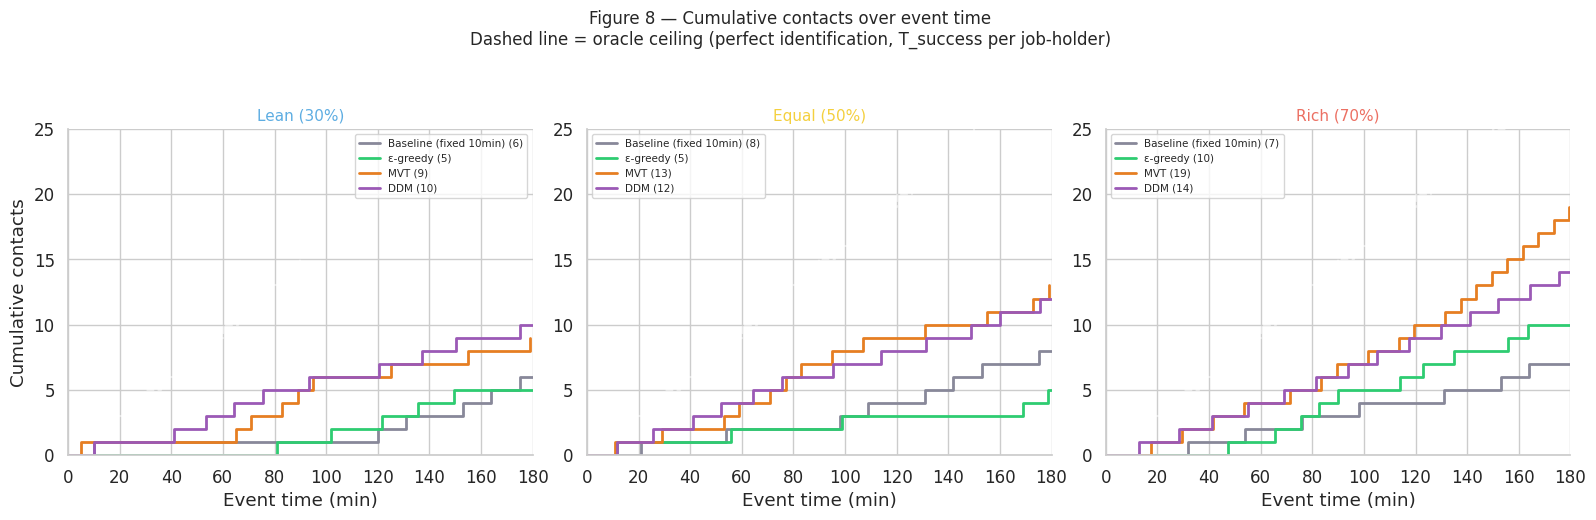

In [ ]:
def fig8_cumulative(all_records):
    """
    Cumulative contacts over event time.
    Adds an "ideal ceiling" line: an oracle agent who instantly identifies
    every job-holder and spends exactly T_SUCCESS on them, skipping everyone else.
    Ceiling slope = employer_pct / (T_SUCCESS + TRAVEL_COST) contacts per minute.
    All panels share x and y axes.
    """
    np.random.seed(42)
    y_max = 25

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "Figure 8 — Cumulative contacts over event time\n"
        "Dashed line = oracle ceiling (perfect identification, T_success per job-holder)",
        fontsize=12, y=1.04)

    for ax, emp in zip(axes, emp_vals):
        people = generate_people(emp)

        # Oracle ceiling: visits only job-holders, spends exactly T_SUCCESS + TRAVEL_COST each
        time_per_contact = T_SUCCESS + TRAVEL_COST
        max_contacts = round(emp * TOTAL_PEOPLE)
        ceiling_times = [0] + [i * time_per_contact for i in range(1, max_contacts + 1)]
        ceiling_conts = list(range(len(ceiling_times)))
        # Clip at EVENT_DURATION
        ceiling_times = [min(t, EVENT_DURATION) for t in ceiling_times]
        ax.step(ceiling_times, ceiling_conts, where="post",
                color="white", lw=1.5, ls="--", alpha=0.5, zorder=1)

        for ag in AGENT_ORDER:
            sub = [r for r in all_records if r["agent"]==ag and r["employer_pct"]==emp]
            if not sub: continue
            best = max(sub, key=lambda x: x["mean"])
            if   ag == "baseline":
                r = simulate_control_agent(people)
            elif ag == "epsilon_greedy":
                r = simulate_epsilon_greedy(people, best.get("epsilon") or 0.5)
            elif ag == "mvt":
                r = simulate_mvt_agent(people, best.get("q") or 0.7,
                                       best.get("lam") or 0.3)
            elif ag == "ddm":
                r = simulate_ddm_agent(people, best.get("q") or 0.8,
                                       best.get("eta") or 0.85)
            log = r["log"]
            times = [0] + [e["time_elapsed"] for e in log]
            conts = [0] + [e["contacts_so_far"] for e in log]
            ax.step(times, conts, where="post", color=AGENT_COLORS[ag], lw=2,
                    label=f"{AGENT_LABELS[ag].replace(chr(10),' ')} ({r['contacts']})",
                    zorder=2)

        ax.set_title(ENV_LABELS[emp], color=ENV_COLORS[emp], fontsize=11)
        ax.set_xlabel("Event time (min)")
        ax.set_ylabel("Cumulative contacts" if ax is axes[0] else "")
        ax.set_xlim(0, EVENT_DURATION)
        ax.set_ylim(0, y_max)
        ax.legend(fontsize=7.5)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("fig8_cumulative.png", dpi=150, bbox_inches="tight")
    plt.show()

fig8_cumulative(all_records)

# Visulazation of the stepwise agent animation (one event)



In [ ]:
AGENT_COLORS_ANIM = {
    "baseline":       "#888888",
    "baseline_v2":    "#4A90D9",
    "epsilon_greedy": "#27AE60",
    "mvt":            "#E67E22",
    "ddm":            "#8E44AD",
}

def animate_agent(agent_name: str, params: dict):
    people = generate_people(params["employer_pct"])
    if   agent_name == "baseline":
        result = simulate_control_agent(people)
    elif agent_name == "epsilon_greedy":
        result = simulate_epsilon_greedy(people, params["epsilon"])
    elif agent_name == "mvt":
        result = simulate_mvt_agent(people, params["q"], params["lam"])
    elif agent_name == "ddm":
        result = simulate_ddm_agent(people, params["q"], params["eta"])

    log = result["log"]
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor("#1a1a2e")
    gs = GridSpec(1, 2, width_ratios=[2.2, 1], figure=fig)
    ax_grid  = fig.add_subplot(gs[0])
    ax_panel = fig.add_subplot(gs[1])
    for ax in [ax_grid, ax_panel]:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        for sp in ax.spines.values(): sp.set_edgecolor("#333355")

    COLS, ROWS = 10, 5
    positions = [(j*2.0, -(i*2.0)) for i in range(ROWS) for j in range(COLS)]
    ax_grid.set_xlim(-1, COLS*2); ax_grid.set_ylim(-ROWS*2, 1.5)
    ax_grid.set_aspect("equal"); ax_grid.axis("off")
    label_str = {"baseline":"Baseline","baseline_v2":"Baseline-v2",
                 "epsilon_greedy":"ε-greedy","mvt":"MVT","ddm":"DDM"}
    ax_grid.set_title(f"{label_str[agent_name]} — one event (emp={params['employer_pct']:.0%})",
                      color="white", fontsize=13, pad=10)

    circles = []
    for idx, (x, y) in enumerate(positions):
        c = plt.Circle((x,y), 0.75, color="#2a2a4a", zorder=2, lw=1.5, ec="#555577")
        ax_grid.add_patch(c); circles.append(c)
        ax_grid.text(x, y, str(idx+1), ha="center", va="center",
                     fontsize=7, color="#aaaacc", zorder=3)

    job_truth = people
    leg_items = [
        mpatches.Patch(color="#2a2a4a", ec="#555577", label="Not visited"),
        mpatches.Patch(color="#F0C040",               label="Current"),
        mpatches.Patch(color="#2ECC71",               label="Contact ✓"),
        mpatches.Patch(color="#884422",               label="Job but too short"),
        mpatches.Patch(color="#C0392B",               label="No job"),
    ]
    ax_grid.legend(handles=leg_items, loc="lower center", ncol=5, fontsize=7.5,
                   facecolor="#1a1a2e", labelcolor="white", framealpha=0.7,
                   bbox_to_anchor=(0.5, -0.06))

    ax_panel.set_xlim(0,1); ax_panel.set_ylim(0,1)
    ax_panel.axis("off"); ax_panel.set_title("Agent state", color="white", fontsize=12)
    state_text = ax_panel.text(0.1, 0.85, "", transform=ax_panel.transAxes,
                               fontsize=11, va="top", color="white", family="monospace",
                               linespacing=2.0)
    ax_success = ax_panel.inset_axes([0.05, 0.05, 0.9, 0.3])
    ax_success.set_facecolor("#111133")
    ax_success.set_title("Contacts over time", color="white", fontsize=9)
    ax_success.tick_params(colors="white", labelsize=7)
    ax_success.set_xlim(0, EVENT_DURATION)
    ax_success.set_ylim(0, max(1, result["contacts"]+1))
    success_line, = ax_success.plot([], [], color=AGENT_COLORS_ANIM[agent_name], lw=2)
    visited_state = {}

    def update(frame):
        entry = log[frame]; curr = entry["person_index"]
        if frame > 0:
            prev_e = log[frame-1]; prev = prev_e["person_index"]
            if prev != curr and prev not in visited_state:
                if prev_e["success"]:          visited_state[prev] = "#2ECC71"
                elif job_truth[prev]:            visited_state[prev] = "#884422"
                else:                           visited_state[prev] = "#C0392B"
        for idx, color in visited_state.items():
            circles[idx].set_facecolor(color); circles[idx].set_edgecolor(color)
        circles[curr].set_facecolor("#F0C040"); circles[curr].set_edgecolor("#FFE080")
        post = entry.get("posterior"); rbar = entry.get("R_bar")
        lines = [f"Person :  {curr+1:2d}/{TOTAL_PEOPLE}",
                 f"Has job:  {'YES' if job_truth[curr] else 'no'}",
                 f"Time   :  {entry['time_in_convo']:.1f} min",
                 f"Contact:  {entry['contacts_so_far']}",
                 f"t total:  {entry['time_elapsed']:.1f} min"]
        if post is not None: lines.append(f"Post.  :  {post:.3f}")
        if rbar is not None: lines.append(f"R_bar  :  {rbar:.5f}")
        state_text.set_text(" ".join(lines))
        times = [log[f]["time_elapsed"] for f in range(frame+1)]
        conts = [log[f]["contacts_so_far"] for f in range(frame+1)]
        success_line.set_data(times, conts)
        return circles + [state_text, success_line]

    ani = animation.FuncAnimation(fig, update, frames=len(log),
                                  interval=400, blit=False, repeat=False)
    plt.tight_layout()
    return ani

In [ ]:
def find_best_params(agent_name, records):
    sub = [r for r in records if r["agent"]==agent_name]
    best = max(sub, key=lambda x: x["mean"])
    print(f"-- Best params for {agent_name} --")
    print(f"  mean contacts : {best['mean']:.2f}")
    print(f"  employer_pct  : {best['employer_pct']}")
    for k in ["q","lam","eta","epsilon"]:
        if best.get(k) is not None: print(f"  {k:12s}: {best[k]}")
    return best

best_params = {ag: find_best_params(ag, all_records)
               for ag in ["baseline","epsilon_greedy","mvt","ddm"]}

-- Best params for baseline --
  mean contacts : 11.25
  employer_pct  : 0.7
-- Best params for epsilon_greedy --
  mean contacts : 8.13
  employer_pct  : 0.7
  epsilon     : 0.1
-- Best params for mvt --
  mean contacts : 21.08
  employer_pct  : 0.7
  q           : 0.8
  lam         : 0.7
-- Best params for ddm --
  mean contacts : 14.33
  employer_pct  : 0.7
  q           : 0.8
  eta         : 0.75


In [ ]:
def build_params(record):
    return {"employer_pct": record["employer_pct"],
            "q":           record.get("q") or 0.7,
            "lam":         record.get("lam") or 0.3,
            "eta":         record.get("eta") or 0.70,
            "epsilon":     record.get("epsilon") or 0.5}

for agent_name in ["baseline","epsilon_greedy","mvt","ddm"]:
    params = build_params(best_params[agent_name])
    print(f"Animating {agent_name} → {params}")
    ani = animate_agent(agent_name, params)
    ani.save(f"animation_{agent_name}_best.gif", writer="pillow", fps=2, dpi=80)
    print(f"  saved.")